# Hotel Booking Survey Analysis

## Task description

Imagine that you own a hotel booking service and have conducted a customer survey.  
A description of the evaluation criteria is provided on the first sheet.

Your task is to perform a quick analysis of the survey results. Below is a set of basic tasks that should be completed using **pandas**. The final answer should be presented as a **Jupyter Notebook** with a clear step-by-step solution.

### Tasks

1. Read the data using **pandas**.
2. Segment each score into **NPS-style groups** (*detractor, promoter, passive*) and define the threshold values used for the segmentation.
3. Show how factor importance changed by quarter, considering only the most important responses (*Important* and *Critically important*).

#### Example of the final table structure

| Factors  | Q3 2023 | Q4 2023 |
|----------|---------|---------|
| Factor 1 | Value   | Value   |

4. Show the number of **detractors, promoters, and passive** by quarter.

#### Example of the final table structure

| Factors  | Q3 2023 Detractor | Q3 2023 Promoter | Q3 2023 Passive | Q3 2023 No response | Q4 2023 Detractor | Q4 2023 Promoter | Q4 2023 Passive | Q4 2023 No response |
|----------|-------------------|------------------|-----------------|---------------------|-------------------|------------------|-----------------|---------------------|
| Factor 1 | Value             | Value            | Value           | Value               | Value             | Value            | Value           | Value               |

## Imports

In [1388]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [1389]:
DATA_FILE_NAME = 'data.csv'

## Load data

In [1390]:
df = pd.read_csv(DATA_FILE_NAME)
df.head()

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,less_than_6_months,9,9,7,4,5,7,10,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,6_to_12_months,7,7,9,8,cannot_evaluate,8,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,6_to_12_months,8,6,8,8,7,6,9,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,less_than_6_months,8,5,cannot_evaluate,cannot_evaluate,cannot_evaluate,cannot_evaluate,cannot_evaluate,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,6_to_12_months,8,5,5,3,3,5,6,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


In [1391]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   response_id                                   57 non-null     int64 
 1   created_at                                    57 non-null     object
 2   service_usage_duration                        57 non-null     object
 3   overall_satisfaction                          57 non-null     int64 
 4   website_app_usability                         57 non-null     object
 5   processing_speed                              57 non-null     object
 6   variety_of_offers                             57 non-null     object
 7   service_quality                               57 non-null     object
 8   price_to_quality_ratio                        57 non-null     object
 9   reviews_ratings_convenience                   57 non-null     object
 10  hote

we have 1 null value

In [1392]:
df.describe()

,response_id,overall_satisfaction
count,5.700000e+01,57.000000
mean,1.497342e+09,7.578947
std,6.718552e+07,1.362080
min,1.437281e+09,4.000000
25%,1.438733e+09,7.000000
50%,1.439024e+09,8.000000
75%,1.570926e+09,8.000000
max,1.578157e+09,10.000000


In [1393]:
df[df.duplicated()]

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance


In [1394]:
df[df['response_id'].duplicated()]

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance


no dups

## Data preparation

Let’s take a look at the data in the columns.

Columns 4–12 contain factor evaluation scores, while columns 13–21 contain factor importance ratings.

In [1395]:
pd.set_option("display.max_colwidth", None)

summary = pd.DataFrame({
    "column": [
        "service_usage_duration",
        "overall_satisfaction",
        "factor_score_columns (4-12)",
        "importance_columns (13-21)",
    ],
    "unique_values": [
        sorted(df["service_usage_duration"].astype(str).unique().tolist()),
        sorted(df["overall_satisfaction"].unique().tolist()),
        sorted(df.iloc[:, 4:13].stack(dropna=False).unique(), key=str),
        sorted(df.iloc[:, 13:22].stack(dropna=False).unique(), key=str),
    ]
})

summary

,column,unique_values
0,service_usage_duration,"[1_to_2_years, 6_to_12_months, less_than_6_months, more_than_2_years]"
1,overall_satisfaction,"[4, 5, 6, 7, 8, 9, 10]"
2,factor_score_columns (4-12),"[1, 10, 2, 3, 4, 5, 6, 7, 8, 9, cannot_evaluate, nan]"
3,importance_columns (13-21),"[cannot_evaluate, critically_important, important, neutral, not_important, not_important_at_all]"


In [1396]:
df.iloc[:, 13:22].stack(dropna=False).value_counts(dropna=False)

important               233
critically_important    174
neutral                  71
cannot_evaluate          17
not_important            11
not_important_at_all      7
Name: count, dtype: int64

In [1397]:
df.iloc[:, 4:13].stack(dropna=False).value_counts(dropna=False)

8                  84
7                  73
9                  70
cannot_evaluate    60
6                  52
10                 39
3                  39
5                  35
4                  31
1                  16
2                  13
NaN                 1
Name: count, dtype: int64

We have 77 'cannot_evaluate' answers which are nan

In [1398]:
df.replace(['cannot_evaluate', float('nan')], None, inplace=True)
df.head()

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,less_than_6_months,9,9,7,4,5,7,10,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,6_to_12_months,7,7,9,8,None,8,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,6_to_12_months,8,6,8,8,7,6,9,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,less_than_6_months,8,5,None,None,None,None,None,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,6_to_12_months,8,5,5,3,3,5,6,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


Let's check type of 'created_at'

In [1399]:
df['created_at'].dtype

dtype('O')

It's object type, convert into datetime type

In [1400]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [1401]:
df['created_at'].dtype

dtype('<M8[ns]')

In [1402]:
df['quarter'] = pd.PeriodIndex(df['created_at'], freq='Q')
df_new = pd.concat([df.iloc[:,:2], df.iloc[:,22], df.iloc[:,2:22]], axis=1)

df_new.head()

,response_id,created_at,quarter,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,2023Q4,less_than_6_months,9,9,7,4,5,7,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,2023Q4,6_to_12_months,7,7,9,8,None,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,2023Q4,6_to_12_months,8,6,8,8,7,6,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,2023Q4,less_than_6_months,8,5,None,None,None,None,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,2023Q4,6_to_12_months,8,5,5,3,3,5,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


In [1403]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   response_id                                   57 non-null     int64         
 1   created_at                                    57 non-null     datetime64[ns]
 2   quarter                                       57 non-null     period[Q-DEC] 
 3   service_usage_duration                        57 non-null     object        
 4   overall_satisfaction                          57 non-null     int64         
 5   website_app_usability                         55 non-null     object        
 6   processing_speed                              53 non-null     object        
 7   variety_of_offers                             54 non-null     object        
 8   service_quality                               44 non-null     object    

## NPS segmentation

The goal of this analysis is to segment users based on their likelihood to recommend the product and identify areas of dissatisfaction

We will divide them into groups according to the [standard approach](https://en.wikipedia.org/wiki/Net_promoter_score): 9–10 points – promoter, 7–8 points – passive, 0–6 points – detractor:

In [1404]:
df_new.head()

,response_id,created_at,quarter,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,2023Q4,less_than_6_months,9,9,7,4,5,7,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,2023Q4,6_to_12_months,7,7,9,8,None,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,2023Q4,6_to_12_months,8,6,8,8,7,6,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,2023Q4,less_than_6_months,8,5,None,None,None,None,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,2023Q4,6_to_12_months,8,5,5,3,3,5,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


In [1405]:
nps_scores = df_new.iloc[:, [0, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]]


In [1406]:
nps_scores.head()

,response_id,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,hotel_info_quality_relevance,payment_security,booking_cancellation_modification
0,1578157017,2023Q4,9,9,7,4,5,7,10,10,10,10
1,1578147391,2023Q4,7,7,9,8,None,8,8,8,6,6
2,1578000638,2023Q4,8,6,8,8,7,6,9,9,10,9
3,1577923109,2023Q4,8,5,None,None,None,None,None,10,None,10
4,1576069400,2023Q4,8,5,5,3,3,5,6,6,6,4


In [1407]:
def status(x):
    if pd.isna(x):
        return x
    
    x = int(x)
    
    if x in (9, 10):
        return 'promoter'
    elif x in (7, 8):
        return 'passive'
    elif 1 <= x <= 6:
        return 'detractor'

    return x

In [1408]:
nps_scores.iloc[:, 2:] = nps_scores.iloc[:, 2:].applymap(status)

nps_scores.head()

,response_id,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,hotel_info_quality_relevance,payment_security,booking_cancellation_modification
0,1578157017,2023Q4,promoter,promoter,passive,detractor,detractor,passive,promoter,promoter,promoter,promoter
1,1578147391,2023Q4,passive,passive,promoter,passive,None,passive,passive,passive,detractor,detractor
2,1578000638,2023Q4,passive,detractor,passive,passive,passive,detractor,promoter,promoter,promoter,promoter
3,1577923109,2023Q4,passive,detractor,None,None,None,None,None,promoter,None,promoter
4,1576069400,2023Q4,passive,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor


In [1409]:
overall_nps_category = nps_scores.iloc[:, 1].value_counts().reset_index()
overall_nps_category.columns = ['category', 'count']
overall_nps_category['share'] = overall_nps_category['count'] / overall_nps_category['count'].sum()

overall_nps_category

,category,count,share
0,2023Q3,32,0.561404
1,2023Q4,25,0.438596


The NPS distribution indicates that most users are passive, suggesting moderate satisfaction without strong loyalty or advocacy

In [1410]:
nps_category = nps_scores.iloc[:, 2:].stack().value_counts().reset_index()
nps_category.columns = ['category', 'count']
nps_category['share'] = nps_category['count'] / nps_category['count'].sum()

nps_category

,category,count,share
0,detractor,196,0.385069
1,passive,193,0.379175
2,promoter,120,0.235756


As we can see, detractor prevails for the most part

In [1411]:
vc = nps_scores.iloc[:, 1].value_counts(normalize=True)

overall_nps = round((vc.get('promoter', 0) - vc.get('detractor', 0)) * 100, 2)
overall_nps

0

Despite a large share of passive users, the NPS remains close to zero, meaning the product does not generate strong positive sentiment or loyalty

Although users rate their overall experience as acceptable, detailed evaluation of product features reveals a high share of detractors (41%), suggesting hidden dissatisfaction with specific aspects of the product.

In [1412]:
nps_cols = nps_scores.columns[2:]

detractor_share = (
    (nps_scores[nps_cols] == 'detractor').sum() /
    nps_scores[nps_cols].notna().sum()
)

detractor_share = detractor_share.reset_index()
detractor_share.columns = ['factor', 'detractor_perc']

detractor_share['detractor_perc'] *= 100

detractor_share = detractor_share.sort_values(
    by='detractor_perc',
    ascending=False
)

detractor_share

,factor,detractor_perc
4,service_quality,70.454545
1,website_app_usability,61.818182
3,variety_of_offers,48.148148
5,price_to_quality_ratio,42.000000
9,booking_cancellation_modification,41.860465
2,processing_speed,41.509434
8,payment_security,28.000000
7,hotel_info_quality_relevance,20.754717
6,reviews_ratings_convenience,18.000000
0,overall_satisfaction,17.543860


In [1413]:
distribution_nps = pd.concat(
    [
        nps_scores[col].value_counts(normalize=True).rename(col)
        for col in nps_cols
    ],
    axis=1
).T.fillna(0)

distribution_nps = distribution_nps.sort_values(
    by='detractor',
    ascending=False
)

distribution_nps = (distribution_nps * 100).round(2)

distribution_nps

,passive,promoter,detractor
service_quality,20.45,9.09,70.45
website_app_usability,30.91,7.27,61.82
variety_of_offers,42.59,9.26,48.15
price_to_quality_ratio,42.00,16.00,42.00
booking_cancellation_modification,18.60,39.53,41.86
processing_speed,45.28,13.21,41.51
payment_security,32.00,40.00,28.00
hotel_info_quality_relevance,30.19,49.06,20.75
reviews_ratings_convenience,46.00,36.00,18.00
overall_satisfaction,63.16,19.30,17.54


The product struggles in usability and service delivery but informational and trust-related aspects perform well

While overall satisfaction appears neutral, detailed analysis reveals significant dissatisfaction in core product areas — particularly usability and service quality — with over 60–70% detractors. This indicates critical friction points that suppress user loyalty and prevent the product from generating strong advocacy

## Analysis of important factors by quarter

We analyzed how the importance of key product factors changed over time.

Only responses marked as ‘important’ or ‘critically important’ were considered

In [1414]:
importance = df_new.iloc[:, [2, 14, 15, 16, 17, 18, 19, 20, 21, 22]]
importance.iloc[:, 1:] = importance.iloc[:, 1:].applymap(lambda x: 1 if (x == 'important' or x == 'critically_important') else 0)
importance.head()

,quarter,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,2023Q4,1,1,1,1,1,1,1,1,0
1,2023Q4,1,1,1,0,1,0,1,0,0
2,2023Q4,1,1,1,1,1,0,0,1,0
3,2023Q4,1,1,1,1,1,1,1,1,1
4,2023Q4,1,1,1,1,1,1,0,0,1


In [1415]:
importance = importance.groupby('quarter').sum()
importance_rel = importance.div(importance.sum(axis=1), axis=0) * 100
importance

,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
quarter,,,,,,,,,
2023Q3,31,31,28,23,28,21,23,17,18
2023Q4,25,25,25,20,20,20,21,15,16


In [1416]:
importance_str = importance.copy()

for col in importance.columns:
    pct = importance[col] / importance.sum(axis=1) * 100
    
    importance_str[col] = (
        importance[col].astype(int).astype(str)
        + ' ('
        + pct.map('{:.2f}%'.format)
        + ')'
    )
    
importance_str

,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
quarter,,,,,,,,,
2023Q3,31 (14.09%),31 (14.09%),28 (12.73%),23 (10.45%),28 (12.73%),21 (9.55%),23 (10.45%),17 (7.73%),18 (8.18%)
2023Q4,25 (13.37%),25 (13.37%),25 (13.37%),20 (10.70%),20 (10.70%),20 (10.70%),21 (11.23%),15 (8.02%),16 (8.56%)


Quarterly importance analysis shows that website/app usability and processing speed remain the most important factors for users across both periods. At the same time, the relative importance of variety of offers and hotel information slightly increased in 2023Q4, while price-to-quality ratio became somewhat less important. Overall, user priorities remained relatively stable across quarters

Focus on improving the most important factors — usability and processing speed — as they represent the strongest drivers of user expectations and have the highest potential impact on satisfaction.

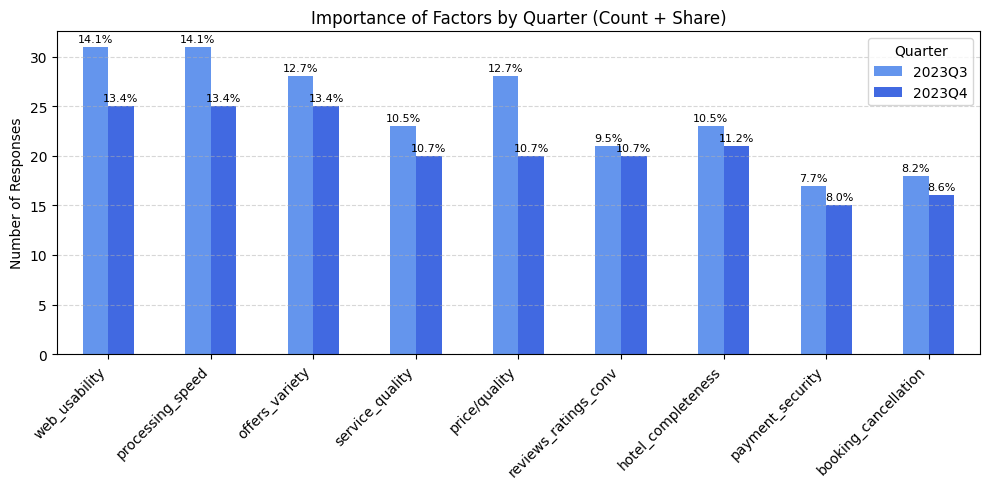

In [1417]:
rename_dict = {
    'website_app_usability_importance': 'web_usability',
    'processing_speed_importance': 'processing_speed',
    'variety_of_offers_importance': 'offers_variety',
    'service_quality_importance': 'service_quality',
    'price_to_quality_ratio_importance': 'price/quality',
    'reviews_ratings_convenience_importance': 'reviews_ratings_conv',
    'hotel_info_quality_relevance_importance': 'hotel_completeness',
    'payment_security_importance': 'payment_security',
    'booking_cancellation_modification_importance': 'booking_cancellation'
}
importance_renamed = importance.rename(columns=rename_dict)
importance_rel_renamed = importance_rel.rename(columns=rename_dict)

ax = importance_renamed.T.plot.bar(
    figsize=(10, 5),
    color=["cornflowerblue", "royalblue"]
)

for container, quarter in zip(ax.containers, importance_rel_renamed.index):
    for bar, pct in zip(container, importance_rel_renamed.loc[quarter]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%',
            ha='center',
            fontsize=8
        )

plt.ylabel('Number of Responses')
plt.title('Importance of Factors by Quarter (Count + Share)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Quarter')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


The most important factors (usability, service quality) also have the highest share of detractors, indicating critical gaps between user expectations and actual experience

## Analysis of detractor / promoters / passive by quarter

In this section, we analyze how customer score distributions changed across quarters for each evaluated factor.


In [1418]:
nps_scores.head()

,response_id,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,hotel_info_quality_relevance,payment_security,booking_cancellation_modification
0,1578157017,2023Q4,promoter,promoter,passive,detractor,detractor,passive,promoter,promoter,promoter,promoter
1,1578147391,2023Q4,passive,passive,promoter,passive,None,passive,passive,passive,detractor,detractor
2,1578000638,2023Q4,passive,detractor,passive,passive,passive,detractor,promoter,promoter,promoter,promoter
3,1577923109,2023Q4,passive,detractor,None,None,None,None,None,promoter,None,promoter
4,1576069400,2023Q4,passive,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor


In [1419]:
nps_scores_factor_status = nps_scores.iloc[:, 1:].copy()
nps_scores_factor_status = nps_scores_factor_status.melt(id_vars=['quarter'], var_name='factors', value_name='status')
nps_scores_factor_status.head()

,quarter,factors,status
0,2023Q4,overall_satisfaction,promoter
1,2023Q4,overall_satisfaction,passive
2,2023Q4,overall_satisfaction,passive
3,2023Q4,overall_satisfaction,passive
4,2023Q4,overall_satisfaction,passive


In [1420]:
nps_scores_factor_status["status"] = (
    nps_scores_factor_status["status"]
    .fillna("no_response")
)

status_order = ["detractor", "promoter", "passive", "no_response"]
quarter_order = sorted(nps_scores_factor_status["quarter"].dropna().unique())

nps_scores_tbl = pd.pivot_table(nps_scores_factor_status, 
                             index=['factors'], 
                             columns=['quarter', 'status'], 
                             aggfunc='size', 
                             fill_value=0)

nps_scores_tbl = nps_scores_tbl.reindex(
    columns=pd.MultiIndex.from_product([quarter_order, status_order]),
    fill_value=0
)


factor_order = [
    "website_app_usability",
    "processing_speed",
    "variety_of_offers",
    "service_quality",
    "price_to_quality_ratio",
    "reviews_ratings_convenience",
    "hotel_info_quality_relevance",
    "payment_security",
    "booking_cancellation_modification",
    "overall_satisfaction",
]

nps_scores_tbl = nps_scores_tbl.reindex(factor_order)
nps_scores_tbl

nps_scores_tbl

2023Q3                               \
                                  detractor promoter passive no_response   
factors                                                                    
website_app_usability                    21        2       7           2   
processing_speed                          9        3      17           3   
variety_of_offers                        14        2      14           2   
service_quality                          17        2       7           6   
price_to_quality_ratio                   10        5      13           4   
reviews_ratings_convenience               5       10      12           5   
hotel_info_quality_relevance              6       16       7           3   
payment_security                          8       10      10           4   
booking_cancellation_modification        10        8       6           8   
overall_satisfaction                      7        6      19           0   

                                     2023Q4                               
                                  detractor promoter passive no_response  
factors                                                                   
website_app_usability                    13        2      10           0  
processing_speed                         13        4       7           1  
variety_of_offers                        12        3       9           1  
service_quality                          14        2       2           7  
price_to_quality_ratio                   11        3       8           3  
reviews_ratings_convenience               4        8      11           2  
hotel_info_quality_relevance              5       10       9           1  
payment_security                          6       10       6           3  
booking_cancellation_modification         8        9       2           6  
overall_satisfaction                      3        5      17           0


- **Website / app usability** had the highest number of detractor scores in both quarters, although the count decreased in Q4 2023.
- **Service quality**, **variety of offers**, and **price-to-quality ratio** also showed relatively high detractor counts compared to other factors.
- **Hotel information quality and relevance** had one of the most positive distributions, with promoter scores consistently exceeding detractor scores.
- **Overall satisfaction** was dominated by passive responses in both quarters, indicating that many respondents gave mid-range rather than extreme evaluations.
- Several factors included a noticeable number of **no-response** cases, which should be considered when interpreting the results.

## Final conclusions

Analysis of NPS distribution by quarter shows that core experience factors — usability, service quality, and processing speed — generate the highest number of detractors. While there is some improvement in usability, processing speed has deteriorated, indicating growing friction in key user journeys

At the same time, overall satisfaction improved slightly due to a decrease in detractors, but this was not accompanied by a meaningful increase in promoters, suggesting limited growth in user loyalty

Improving core experience factors should be the top priority, as they have both high importance and high dissatisfaction, representing the biggest opportunity to increase NPS